# Decision Tree Regressor

#### Pedro Mauri Mtz - A01029143

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.tree import plot_tree

### Data science

In [3]:
df = pd.read_csv(os.path.join(ROOT, "Datasets", "laptop.csv"))
df_copy = df.copy()
df.head()

,Company,TypeName,Ram,OpSys,Weight,Touchscreen,CpuCompany,ClockSpeed,Flash Storage,HDD,Hybrid,SSD,GPU,Ppi,Price
0,Apple,Ultrabook,8,macOS,1.37,0,Intel,2.3,0.000,0.0,0.0,0.128,Intel,312.781955,71378.6832
1,Apple,Ultrabook,8,macOS,1.34,0,Intel,1.8,0.128,0.0,0.0,0.000,Intel,175.939850,47895.5232
2,HP,Notebook,8,No,1.86,0,Intel,2.5,0.000,0.0,0.0,0.256,Intel,192.307692,30636.0000
3,Apple,Ultrabook,16,macOS,1.83,0,Intel,2.7,0.000,0.0,0.0,0.512,AMD,303.896104,135195.3360
4,Apple,Ultrabook,8,macOS,1.37,0,Intel,3.1,0.000,0.0,0.0,0.256,Intel,312.781955,96095.8080


In [4]:
df.nunique()

Company           19
TypeName           6
Ram                9
OpSys              7
Weight           171
Touchscreen        2
CpuCompany         3
ClockSpeed        25
Flash Storage      7
HDD                6
Hybrid             3
SSD               13
GPU                4
Ppi               39
Price            791
dtype: int64

In [5]:
df.dtypes

Company           object
TypeName          object
Ram                int64
OpSys             object
Weight           float64
Touchscreen        int64
CpuCompany        object
ClockSpeed       float64
Flash Storage    float64
HDD              float64
Hybrid           float64
SSD              float64
GPU               object
Ppi              float64
Price            float64
dtype: object

In [6]:
df.isna().sum()

Company          0
TypeName         0
Ram              0
OpSys            0
Weight           0
Touchscreen      0
CpuCompany       0
ClockSpeed       0
Flash Storage    0
HDD              0
Hybrid           0
SSD              0
GPU              0
Ppi              0
Price            0
dtype: int64

In [7]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [8]:
x = pd.get_dummies(x, drop_first = True)

In [9]:
x.head()

,Ram,Weight,Touchscreen,ClockSpeed,Flash Storage,HDD,Hybrid,SSD,Ppi,Company_Apple,...,OpSys_Linux,OpSys_Mac,OpSys_No,OpSys_Windows,OpSys_macOS,CpuCompany_Intel,CpuCompany_Samsung,GPU_ARM,GPU_Intel,GPU_Nvidia
0,8,1.37,0,2.3,0.000,0.0,0.0,0.128,312.781955,True,...,False,False,False,False,True,True,False,False,True,False
1,8,1.34,0,1.8,0.128,0.0,0.0,0.000,175.939850,True,...,False,False,False,False,True,True,False,False,True,False
2,8,1.86,0,2.5,0.000,0.0,0.0,0.256,192.307692,False,...,False,False,True,False,False,True,False,False,True,False
3,16,1.83,0,2.7,0.000,0.0,0.0,0.512,303.896104,True,...,False,False,False,False,True,True,False,False,False,False
4,8,1.37,0,3.1,0.000,0.0,0.0,0.256,312.781955,True,...,False,False,False,False,True,True,False,False,True,False


In [10]:
y.head()

0     71378.6832
1     47895.5232
2     30636.0000
3    135195.3360
4     96095.8080
Name: Price, dtype: float64

### Create datasets

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

### Arbol de Decisión de Regresión

In [12]:
# DTR_model = DecisionTreeRegressor(max_depth = 18, min_samples_leaf = 8, min_samples_split = 10, ccp_alpha = 0.1)
DTR_model = DecisionTreeRegressor()

### Training

In [13]:
# Train the model
DTR_model.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [14]:
y_pred_train_data = DTR_model.predict(x_train)
r2_train_data = r2_score(y_train, y_pred_train_data)
print(f"Model R2 Score on Training Data: {r2_train_data}")

Model R2 Score on Training Data: 0.995988469932421


### Testing

In [15]:
# Test the model
y_pred = DTR_model.predict(x_test)

In [16]:
r2 = r2_score(y_test, y_pred)
print(f"Model R2 Score on Test Data: {r2}")

Model R2 Score on Test Data: 0.6901824040123306


## Visualize the Tree

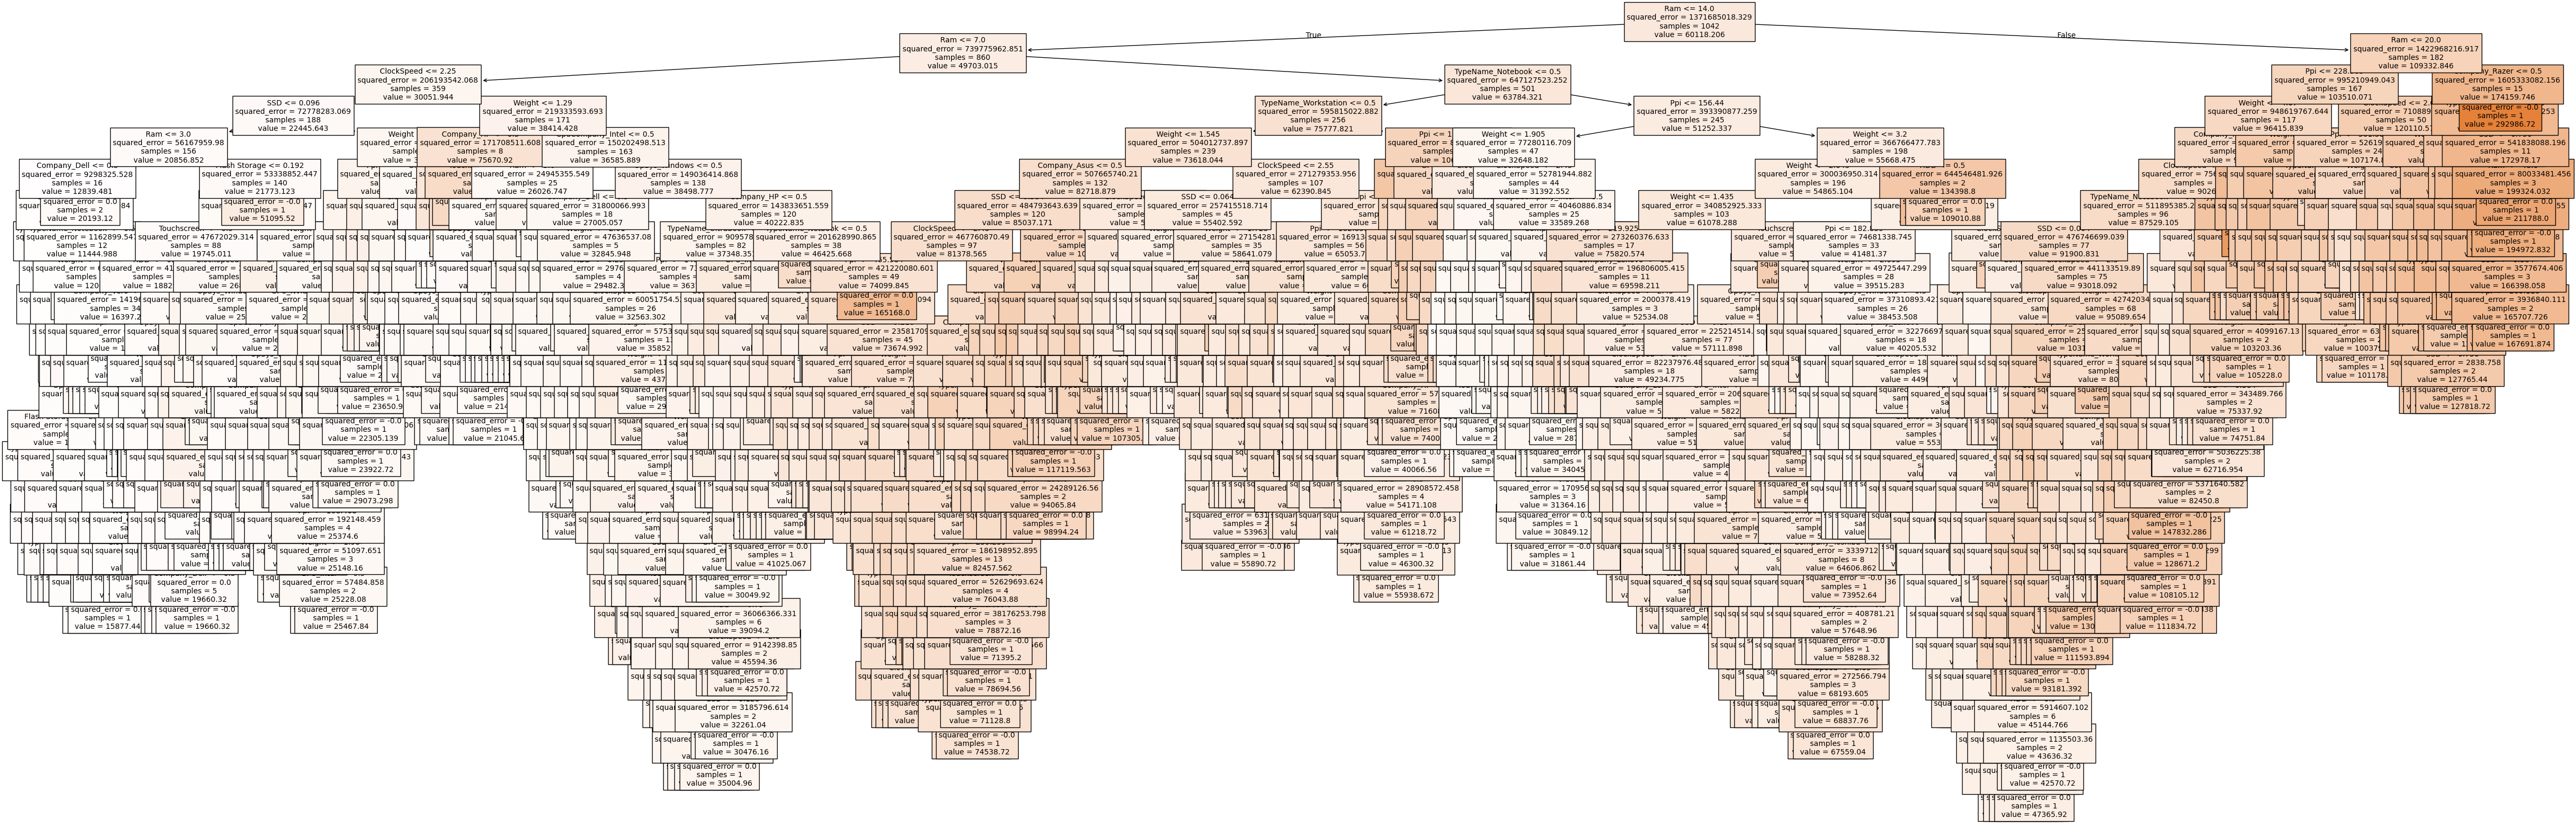

In [ ]:
plt.figure(figsize = (60, 20))
plot_tree(DTR_model, filled = True, feature_names = x.columns, fontsize = 10)
plt.show()